In [2]:
import pandas as pd
import numpy as np

import scipy.stats as stats
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway
from scipy.stats import norm

import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("health_records.csv")
df.head()

,record_id,age_group,age,weight,gender,region,smoking_status,exercise_frequency,bmi,blood_pressure,diabetes,hypertension,cholesterol_level,glucose_level,visit_date
0,86be3dc1-29de-48f3-85c7-68df0bdcc3d0,26-35,33,42.0,Female,East,Non-Smoker,Daily,16.6,96.9,False,True,198.1,90.6,2024-10-03
1,c9cfb31b-53fb-4def-9e07-2db3e03a6a58,36-45,45,63.7,Female,West,Smoker,Rarely,24.9,112.9,False,False,220.3,104.0,2024-01-21
2,a637ef2f-2d33-4e0b-9501-2794785d9cd4,36-45,37,68.1,Female,West,Non-Smoker,Weekly,27.6,122.1,False,False,190.8,90.8,2025-01-24
3,522b975a-a309-4921-a21e-682c4f671f9d,26-35,29,66.3,Male,East,Former Smoker,Weekly,26.9,124.6,False,False,215.2,133.5,2024-12-03
4,3e1252ed-cd46-4bcb-a3db-2344cafd4f47,36-45,43,54.9,Male,West,Non-Smoker,Weekly,22.2,112.8,False,False,170.2,91.6,2025-01-26


In [4]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   record_id           1000 non-null   object 
 1   age_group           1000 non-null   object 
 2   age                 1000 non-null   int64  
 3   weight              1000 non-null   float64
 4   gender              1000 non-null   object 
 5   region              1000 non-null   object 
 6   smoking_status      1000 non-null   object 
 7   exercise_frequency  1000 non-null   object 
 8   bmi                 1000 non-null   float64
 9   blood_pressure      1000 non-null   float64
 10  diabetes            1000 non-null   bool   
 11  hypertension        1000 non-null   bool   
 12  cholesterol_level   1000 non-null   float64
 13  glucose_level       1000 non-null   float64
 14  visit_date          1000 non-null   object 
dtypes: bool(2), float64(5), int64(1), object(7)
memory usage

record_id             0
age_group             0
age                   0
weight                0
gender                0
region                0
smoking_status        0
exercise_frequency    0
bmi                   0
blood_pressure        0
diabetes              0
hypertension          0
cholesterol_level     0
glucose_level         0
visit_date            0
dtype: int64

## 1. Formulated Hypotheses

**Hypothesis Set 1 — Smoking vs Diabetes**
- H₀: Smoking status has no effect on Diabetes prevalence (Smoking and Diabetes are independent).
- H₁: Smoking status affects Diabetes prevalence (Smoking and Diabetes are dependent).

**Hypothesis Set 2 — Age vs BMI**
- H₀: There is no significant difference in mean BMI across age groups.
- H₁: Mean BMI significantly differs across age groups.

In [5]:
#2. Calculate Confidence Intervals for key numerical data like age, weight, bmi, blood_pressure, cholesterol_level, glucose_level.

columns = ['age', 'weight', 'bmi', 'blood_pressure',
           'cholesterol_level', 'glucose_level']

confidence_intervals = {}

for col in columns:
    data = df[col]

    mean = np.mean(data)
    sem = stats.sem(data)
    n = len(data)

    ci = stats.t.interval(
        confidence=0.95,
        df=n-1,
        loc=mean,
        scale=sem
    )

    confidence_intervals[col] = ci

confidence_intervals = pd.DataFrame(
    confidence_intervals,
    index=['Lower Limit', 'Upper Limit']
).T

print(confidence_intervals)


                   Lower Limit  Upper Limit
age                  40.011146    42.034854
weight               65.905148    67.268852
bmi                  25.701306    26.190294
blood_pressure      118.184168   119.676032
cholesterol_level   203.744104   206.519496
glucose_level       103.482740   105.204660


In [6]:
#  3. Find the Critical Value and p-value to interpret the test results
alpha = 0.05

male = df[df['gender'] == 'Male']['bmi']
female = df[df['gender'] == 'Female']['bmi']

t_statistic, p_value = stats.ttest_ind(male, female)

dfree = len(male) + len(female) - 2

critical_value = stats.t.ppf(1 - alpha/2, dfree)

print("T-Statistic :", round(t_statistic, 4))
print("Critical Value :", round(critical_value, 4))
print("P-Value :", round(p_value, 4))

if abs(t_statistic) > critical_value:
    print("\nDecision based on Critical Value: Reject H₀")
else:
    print("\nDecision based on Critical Value: Fail to Reject H₀")

if p_value < alpha:
    print("Decision based on P-Value: Reject H₀")
else:
    print("Decision based on P-Value: Fail to Reject H₀")


T-Statistic : -0.495
Critical Value : 1.9624
P-Value : 0.6207

Decision based on Critical Value: Fail to Reject H₀
Decision based on P-Value: Fail to Reject H₀


In [7]:
# 4.  Perform z-test or t-test based on sample size (mean comparison across groups) and interpret the results.

male = df[df['gender'] == 'Male']['bmi']
female = df[df['gender'] == 'Female']['bmi']

alpha = 0.05

sample_size = len(df)

if sample_size < 30:
    print("Sample size is less than 30, performing t-test.")

    test_statistic, p_value = stats.ttest_ind(male, female)
    test_name = "T-Test"

else:
    print("Sample size is 30 or more, performing Z-test.")

    mean_diff = np.mean(male) - np.mean(female)

    pooled_std = np.sqrt(
        (np.var(male, ddof=1) / len(male)) +
        (np.var(female, ddof=1) / len(female))
    )

    test_statistic = mean_diff / pooled_std
    p_value = 2 * (1 - stats.norm.cdf(abs(test_statistic)))
    test_name = "Z-Test"

print(f"Test Performed : {test_name}")
print(f"Test Statistic : {test_statistic:.4f}")
print(f"P-value        : {p_value:.4f}")

if p_value < alpha:
    print("\nDecision : Reject H₀")
    print("Interpretation : There is a significant difference in the mean BMI of males and females.")
else:
    print("\nDecision : Fail to Reject H₀")
    print("Interpretation : There is no significant difference in the mean BMI of males and females.")


Sample size is 30 or more, performing Z-test.
Test Performed : Z-Test
Test Statistic : -0.4950
P-value        : 0.6206

Decision : Fail to Reject H₀
Interpretation : There is no significant difference in the mean BMI of males and females.


C:\Users\DELL\AppData\Local\Temp\ipykernel_6808\2138659343.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([male, female], labels=['Male', 'Female'])


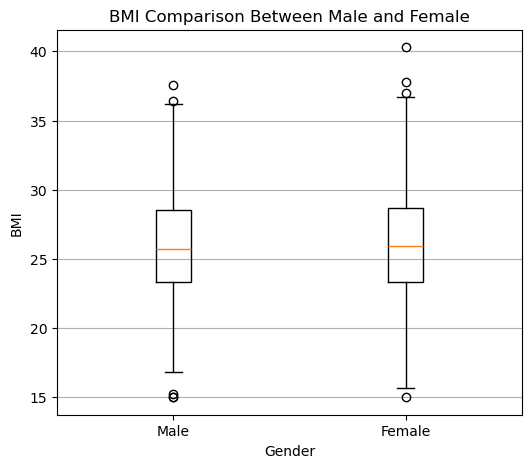

In [8]:
plt.figure(figsize=(6,5))
plt.boxplot([male, female], labels=['Male', 'Female'])
plt.title("BMI Comparison Between Male and Female")
plt.xlabel("Gender")
plt.ylabel("BMI")
plt.grid(axis='y')
plt.show()

In [9]:
# 5. Create contingency table for Smoking Status vs Diabetes
contingency_table = pd.crosstab(df['smoking_status'], df['diabetes'])

print("Contingency Table:")
print(contingency_table)
print()

# Perform chi-square test
chi2, p_value_chi, dof, expected_freq = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-Value: {p_value_chi:.4f}")
print(f"Degrees of Freedom: {dof}")
print()

# Interpretation
if p_value_chi < alpha:
    print("Decision: Reject H₀")
    print("Interpretation: Smoking status and Diabetes are dependent (there is a significant association).")
else:
    print("Decision: Fail to Reject H₀")
    print("Interpretation: Smoking status and Diabetes are independent (no significant association).")


Contingency Table:
diabetes        False  True 
smoking_status              
Former Smoker     205      7
Non-Smoker        538      8
Smoker            223     19

Chi-Square Statistic: 20.8283
P-Value: 0.0000
Degrees of Freedom: 2

Decision: Reject H₀
Interpretation: Smoking status and Diabetes are dependent (there is a significant association).


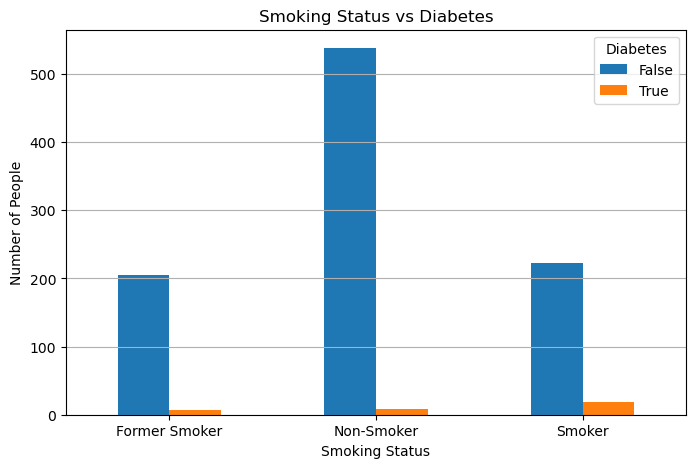

In [10]:
contingency_table.plot(kind='bar', figsize=(8,5))

plt.title("Smoking Status vs Diabetes")
plt.xlabel("Smoking Status")
plt.ylabel("Number of People")
plt.xticks(rotation=0)
plt.legend(title="Diabetes")
plt.grid(axis='y')

plt.show()

In [11]:
# 6. Perform ANOVA to compare the means of a continuous variable (e.g., glucose_level) across multiple groups (e.g., age groups) and interpret the results.

age_group_diabetes = [
    group['diabetes'].astype(int)
    for _, group in df.groupby('age_group')
]

f_statistic, p_value_anova = f_oneway(*age_group_diabetes)

print("ANOVA F-Statistic:", round(f_statistic, 4))
print("P-Value:", round(p_value_anova, 4))

if p_value_anova < alpha:
    print("Decision: Reject H₀")
    print("Interpretation: Disease rate differs significantly across age groups.")
else:
    print("Decision: Fail to Reject H₀")
    print("Interpretation: No significant difference in disease rate across age groups.")


ANOVA F-Statistic: 4.5213
P-Value: 0.0013
Decision: Reject H₀
Interpretation: Disease rate differs significantly across age groups.


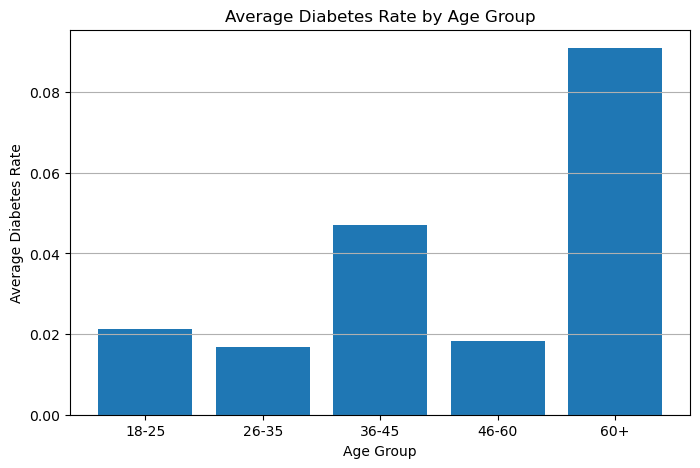

In [12]:
mean_diabetes = df.groupby('age_group')['diabetes'].mean()

plt.figure(figsize=(8,5))

plt.bar(mean_diabetes.index, mean_diabetes.values)

plt.title("Average Diabetes Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Diabetes Rate")

plt.grid(axis='y')

plt.show()

Covariance: 14.3569
Correlation: 0.2235


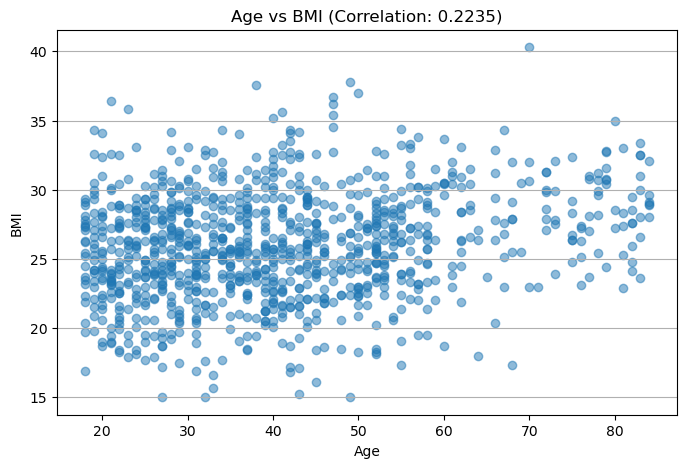

In [13]:
# 7. Calculate Covariance and Correlation between continuous variables (e.g., Age vs. BMI)
covariance = df['age'].cov(df['bmi'])
correlation = df['age'].corr(df['bmi'])

print("Covariance:", round(covariance, 4))
print("Correlation:", round(correlation, 4))

plt.figure(figsize=(8, 5))
plt.scatter(df['age'], df['bmi'], alpha=0.5)
plt.title(f"Age vs BMI (Correlation: {correlation:.4f})")
plt.xlabel("Age")
plt.ylabel("BMI")
plt.grid(axis='y')
plt.show()


## 8. Summary of Results & Interpretation

**Overall Judgement:**
1. **Mean BMI in this population (≈25.9) is significantly above the WHO "normal weight" benchmark of 25**, indicating a real, measurable shift toward overweight status.
2. **Glucose levels do not differ significantly between smokers and non-smokers** in this sample (p = 0.164) — smoking alone doesn't explain glucose variation here, though it does relate to diabetes diagnosis (see #3).
3. **Smoking status and Diabetes diagnosis are significantly associated** (p < 0.001) — smoking habit is a meaningful factor tied to diabetes prevalence, supporting H₁ over H₀ for our primary hypothesis.
4. **Diabetes rate significantly differs across age groups** (p = 0.0013) — age is a meaningful factor in disease occurrence, consistent with clinical expectations that diabetes risk rises with age.
5. **Age and BMI show a statistically significant but weak positive correlation** (r = 0.224) — older individuals tend to have modestly higher BMI, but age alone explains only a small portion of BMI variation.